<a href="https://colab.research.google.com/github/BahruzHuseynov/Portfolio/blob/main/Deep_Learning_Projects/CNN_Architecture/Tensorflow/CNN3_VGG_Net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

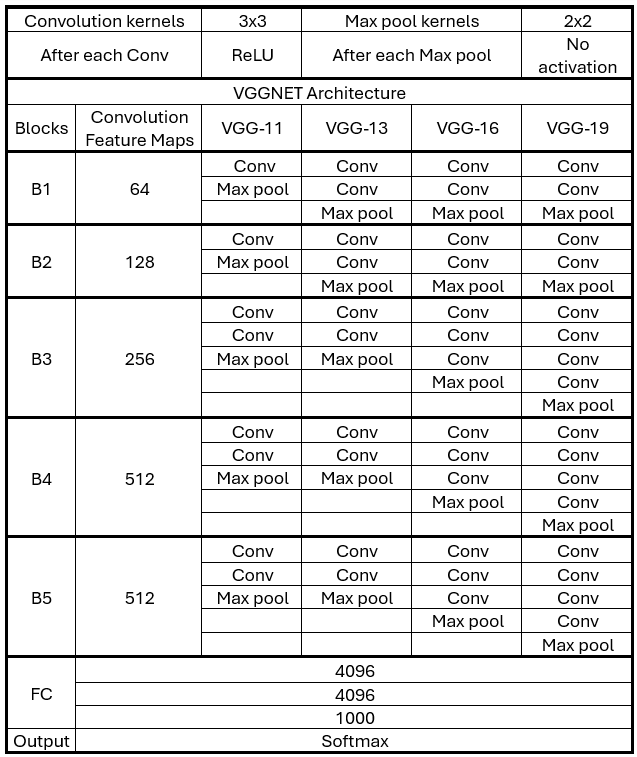

In [1]:
from PIL import Image
Image.open("VGG_NET_Architecture.png")

# Convolution paddings: 1
# Convolution strides: 1
# Max Pool strides: 2
# Max Pool paddings = 0

### VGG 19 architecture
<img src = "https://www.researchgate.net/publication/325137356/figure/fig2/AS:670371271413777@1536840374533/llustration-of-the-network-architecture-of-VGG-19-model-conv-means-convolution-FC-means.jpg">

### Import Libraries

In [2]:
import tensorflow as tf
from tensorflow import keras
from keras import Model, Sequential, layers, optimizers, losses, metrics

### Dataset Preparation

In [3]:
!pip install -q kaggle

In [7]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"hbahruz","key":"4f925bc35f1b4f8677fc6f8061cceb06"}'}

In [8]:
!kaggle datasets download -d akhiljethwa/forest-vs-desert

Dataset URL: https://www.kaggle.com/datasets/akhiljethwa/forest-vs-desert
License(s): CC-BY-NC-SA-4.0
 93% 7.00M/7.54M [00:01<00:00, 8.20MB/s]
100% 7.54M/7.54M [00:01<00:00, 5.38MB/s]


In [9]:
import zipfile

crab_species_zip = 'forest-vs-desert.zip'

def extract_zip(file_path, extract_to='.'):
    with zipfile.ZipFile(file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

extract_zip(crab_species_zip, 'forest_vs_desert')

In [10]:
batch_size = 8
img_height = 224
img_width = 224

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'forest_vs_desert/Data',
    validation_split=0.2,  # Use 20% of training data for validation
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'forest_vs_desert/Data',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=1024)
val_ds = val_ds.cache().prefetch(buffer_size=1024)

Found 802 files belonging to 2 classes.
Using 642 files for training.
Found 802 files belonging to 2 classes.
Using 160 files for validation.


### VGG Net with TensorFlow

In [11]:
class VGG(Model):
    def __init__(self, num_classes, model_type="vgg11", in_channels=3):
        super(VGG, self).__init__()

        self.num_classes = num_classes
        models = ["vgg11", "vgg13", "vgg16", "vgg19"]
        self.mod = None
        if model_type in models:
            self.mod = models.index(model_type)

        b1 = [1, 2, 2, 2]
        b2 = [1, 2, 2, 2]
        b3 = [2, 2, 3, 4]
        b4 = [2, 2, 3, 4]
        b5 = [2, 2, 3, 4]
        filters = [in_channels, 64, 128, 256, 512, 512]

        if self.mod is not None:
            self.block1 = Sequential()
            for i in range(b1[self.mod]):
                layer = layers.Conv2D(filters[1], kernel_size = 3, strides = (1, 1), padding='same', activation='relu')
                self.block1.add(layer)
            self.block1.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

            self.block2 = Sequential()
            for i in range(b2[self.mod]):
                layer = layers.Conv2D(filters[2], kernel_size = 3, strides = (1, 1), padding='same', activation='relu')
                self.block2.add(layer)
            self.block2.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

            self.block3 = Sequential()
            for i in range(b3[self.mod]):
                layer = layers.Conv2D(filters[3], kernel_size = 3, strides = (1, 1), padding='same', activation='relu')
                self.block3.add(layer)
            self.block3.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

            self.block4 = Sequential()
            for i in range(b4[self.mod]):
                layer = layers.Conv2D(filters[4], kernel_size = 3, strides = (1, 1), padding='same', activation='relu')
                self.block4.add(layer)
            self.block4.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

            self.block5 = Sequential()
            for i in range(b5[self.mod]):
                layer = layers.Conv2D(filters[5], kernel_size = 3, strides = (1, 1), padding='same', activation='relu')
                self.block5.add(layer)
            self.block5.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

        self.classifier = Sequential([
            layers.Flatten(),
            layers.Dense(4096, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(4096, activation='relu'),
            layers.Dropout(0.5),
            layers.Dense(self.num_classes, activation='softmax')
        ])

    def call(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        return self.classifier(x)

In [13]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    strategy = tf.distribute.MirroredStrategy()
    print(f"Number of GPUs: {len(gpus)}")
else:
    strategy = tf.distribute.get_strategy()
    print("No GPUs available, using default strategy")

Number of GPUs: 1


In [16]:
with strategy.scope():
    model = VGG(num_classes=2, model_type="vgg19")
    optimizer = optimizers.Adam(learning_rate=0.01)
    loss_fn = losses.SparseCategoricalCrossentropy()
    metric = metrics.SparseCategoricalAccuracy()

    model.compile(optimizer=optimizer, loss=loss_fn, metrics=[metric])

In [17]:
model.fit(train_ds, epochs=5, validation_data=val_ds)

Epoch 1/5
81/81 [==============================] - 26s 213ms/step - loss: 3130151403520.0000 - sparse_categorical_accuracy: 0.5234 - val_loss: 5520.6313 - val_sparse_categorical_accuracy: 0.5250
Epoch 2/5
81/81 [==============================] - 16s 196ms/step - loss: 7314.3066 - sparse_categorical_accuracy: 0.5218 - val_loss: 9.6010 - val_sparse_categorical_accuracy: 0.5250
Epoch 3/5
81/81 [==============================] - 16s 194ms/step - loss: 6.0111 - sparse_categorical_accuracy: 0.4891 - val_loss: 0.6988 - val_sparse_categorical_accuracy: 0.5250
Epoch 4/5
81/81 [==============================] - 16s 198ms/step - loss: 0.7593 - sparse_categorical_accuracy: 0.4766 - val_loss: 0.7496 - val_sparse_categorical_accuracy: 0.4750
Epoch 5/5
81/81 [==============================] - 16s 194ms/step - loss: 0.7207 - sparse_categorical_accuracy: 0.4844 - val_loss: 0.7388 - val_sparse_categorical_accuracy: 0.4750
